In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

np.random.seed(42)

In [2]:
from google.colab import files

print("Please upload your sleep_dataset.csv file...")
uploaded = files.upload()          # file-picker dialog will appear

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\nLoaded '{filename}'  →  shape: {df.shape}")
print(df.head())

Please upload your sleep_dataset.csv file...


Saving sleep_dataset.csv to sleep_dataset.csv

Loaded 'sleep_dataset.csv'  →  shape: (1000, 13)
   Person ID  Gender  Age Occupation  Sleep Duration  Quality of Sleep  \
0          1    Male   40     Lawyer             6.2                 4   
1          2  Female   57     Lawyer             6.0                 5   
2          3  Female   58    Teacher             6.9                 5   
3          4  Female   72    Manager             5.9                 4   
4          5  Female   46    Student             5.5                 6   

   Physical Activity Level  Stress Level BMI Category Blood Pressure  \
0                       28             9       Normal         125/88   
1                       38             5   Overweight         139/95   
2                       39             6   Overweight         132/91   
3                       37             7       Normal         132/84   
4                       44             7   Overweight         124/84   

   Heart Rate  Daily Steps

In [3]:
# ============================================================
# SECTION 2 — DATA PREPROCESSING
# ============================================================

# ── 2a. Drop unused column ─────────────────────────────────
df.drop(columns=["Person ID"], inplace=True)

# ── 2b. Fill NaN in Sleep Disorder → "None" (no disorder) ──
# 334 rows have no disorder label stored as NaN in the CSV
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

print("\nClass distribution after filling NaN:")
print(df["Sleep Disorder"].value_counts())

# ── 2c. Split Blood Pressure "125/88" → Systolic, Diastolic ─
df[["Systolic_BP", "Diastolic_BP"]] = (
    df["Blood Pressure"].str.split("/", expand=True).astype(float)
)
df.drop(columns=["Blood Pressure"], inplace=True)

# ── 2d. Rename columns (remove spaces) ──────────────────────
df.rename(columns={
    "Sleep Disorder":        "Sleep_Disorder",
    "Sleep Duration":        "Sleep_Duration",
    "Quality of Sleep":      "Quality_of_Sleep",
    "Physical Activity Level": "Physical_Activity",
    "Stress Level":          "Stress_Level",
    "BMI Category":          "BMI_Category",
    "Heart Rate":            "Heart_Rate",
    "Daily Steps":           "Daily_Steps",
}, inplace=True)

# ── 2e. Label-encode categorical columns ────────────────────
le_gender     = LabelEncoder()
le_occupation = LabelEncoder()
le_bmi        = LabelEncoder()
le_target     = LabelEncoder()

df["Gender_enc"]     = le_gender.fit_transform(df["Gender"])
df["Occupation_enc"] = le_occupation.fit_transform(df["Occupation"])
df["BMI_enc"]        = le_bmi.fit_transform(df["BMI_Category"])
df["Target"]         = le_target.fit_transform(df["Sleep_Disorder"])

class_names = le_target.classes_
print("\nEncoded classes:", class_names)

# ── 2f. Engineered interaction features (Section 2.2) ───────
df["BP_Pulse"]           = df["Systolic_BP"] - df["Diastolic_BP"]
df["Sleep_Stress_Ratio"] = df["Sleep_Duration"] / df["Stress_Level"]
df["Quality_Stress"]     = df["Quality_of_Sleep"] / df["Stress_Level"]
df["Age_Sleep"]          = df["Age"] * df["Sleep_Duration"]
df["Steps_Activity"]     = df["Daily_Steps"] * df["Physical_Activity"]

# ── 2g. Final feature matrix ─────────────────────────────────
FEATURE_COLS = [
    "Age", "Sleep_Duration", "Quality_of_Sleep", "Stress_Level",
    "Heart_Rate", "Daily_Steps", "Systolic_BP", "Diastolic_BP",
    "Physical_Activity",
    "Gender_enc", "Occupation_enc", "BMI_enc",
    "BP_Pulse", "Sleep_Stress_Ratio", "Quality_Stress",
    "Age_Sleep", "Steps_Activity",
]

X = df[FEATURE_COLS].values
y = df["Target"].values

print("\nFeature matrix shape:", X.shape)
print("No missing values:", pd.DataFrame(X, columns=FEATURE_COLS).isnull().sum().sum() == 0)


Class distribution after filling NaN:
Sleep Disorder
None           334
Insomnia       333
Sleep Apnea    333
Name: count, dtype: int64

Encoded classes: ['Insomnia' 'None' 'Sleep Apnea']

Feature matrix shape: (1000, 17)
No missing values: True


In [4]:
# ============================================================
# SECTION 3 — TRAIN / TEST SPLIT  (80 / 20 stratified)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")


Train: 800 samples | Test: 200 samples


In [5]:
# ============================================================
# SECTION 4 — MODEL TRAINING
# ============================================================

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Extra Trees
et = ExtraTreesClassifier(n_estimators=100, random_state=42)
et.fit(X_train, y_train)

# SVM — Z-score normalise inputs first
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
svm.fit(X_train_sc, y_train)

print("\nAll three models trained successfully.")


All three models trained successfully.


In [6]:
# ============================================================
# SECTION 5 — STRATIFIED 5-FOLD CROSS-VALIDATION
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rf  = cross_val_score(rf,  X_train,    y_train, cv=cv, scoring="accuracy")
cv_et  = cross_val_score(et,  X_train,    y_train, cv=cv, scoring="accuracy")
cv_svm = cross_val_score(svm, X_train_sc, y_train, cv=cv, scoring="accuracy")

print("\n── 5-Fold CV Accuracy ──")
print(f"Random Forest : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
print(f"Extra Trees   : {cv_et.mean():.4f} ± {cv_et.std():.4f}")
print(f"SVM           : {cv_svm.mean():.4f} ± {cv_svm.std():.4f}")


── 5-Fold CV Accuracy ──
Random Forest : 0.9437 ± 0.0181
Extra Trees   : 0.9475 ± 0.0094
SVM           : 0.9475 ± 0.0146


In [7]:
# ============================================================
# SECTION 6 — TEST-SET EVALUATION  (Table 2)
# ============================================================
models = {
    "Random Forest": (rf,  X_test),
    "Extra Trees":   (et,  X_test),
    "SVM":           (svm, X_test_sc),
}

results = {}
for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro")
    results[name] = {"Accuracy": acc, "F1-Score (Macro)": f1}
    print(f"\n── {name} ──")
    print(f"  Accuracy : {acc:.4f}  |  F1-Score : {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names))

results_df = pd.DataFrame(results).T
print("\nTable 2. Performance evaluation of the models")
print(results_df.to_string())


── Random Forest ──
  Accuracy : 0.9500  |  F1-Score : 0.9499
              precision    recall  f1-score   support

    Insomnia       0.94      0.91      0.92        67
        None       1.00      1.00      1.00        67
 Sleep Apnea       0.91      0.94      0.93        66

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200


── Extra Trees ──
  Accuracy : 0.9450  |  F1-Score : 0.9448
              precision    recall  f1-score   support

    Insomnia       0.94      0.90      0.92        67
        None       1.00      1.00      1.00        67
 Sleep Apnea       0.90      0.94      0.92        66

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200


── SVM ──
  Accuracy : 0.9250  |  F1-Score : 0.9248
              precision    recall  f1-score   support

    In

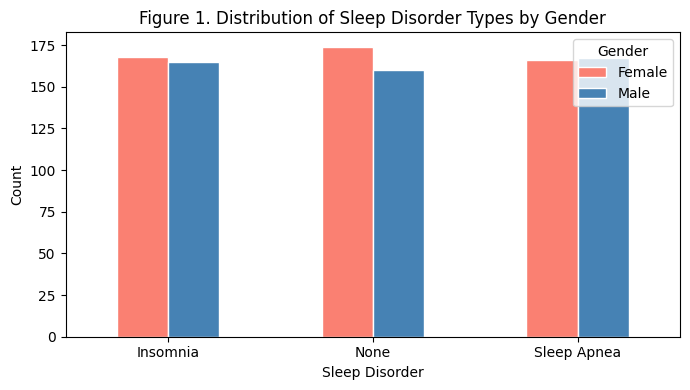

In [9]:
# ============================================================
# SECTION 7 — FIGURES
# ============================================================

palette = {"None": "green", "Insomnia": "red", "Sleep Apnea": "blue"}

# ── Figure 1: Gender distribution by disorder type ──────────
fig, ax = plt.subplots(figsize=(7, 4))
gender_counts = df.groupby(["Sleep_Disorder", "Gender"]).size().unstack(fill_value=0)
gender_counts.plot(kind="bar", ax=ax, color=["salmon", "steelblue"], edgecolor="white")
ax.set_title("Figure 1. Distribution of Sleep Disorder Types by Gender")
ax.set_xlabel("Sleep Disorder")
ax.set_ylabel("Count")
ax.legend(title="Gender")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


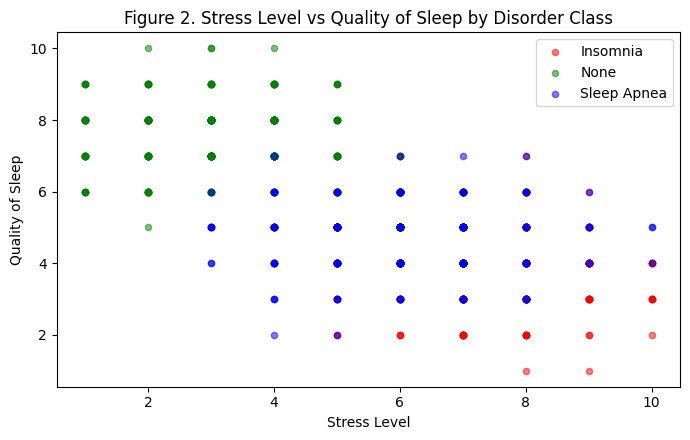

In [10]:
# ── Figure 2: Stress Level vs Quality of Sleep ──────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
for disorder, grp in df.groupby("Sleep_Disorder"):
    ax.scatter(grp["Stress_Level"], grp["Quality_of_Sleep"],
               label=disorder, alpha=0.5, s=20, c=palette.get(disorder, "grey"))
ax.set_xlabel("Stress Level")
ax.set_ylabel("Quality of Sleep")
ax.set_title("Figure 2. Stress Level vs Quality of Sleep by Disorder Class")
ax.legend()
plt.tight_layout()
plt.show()

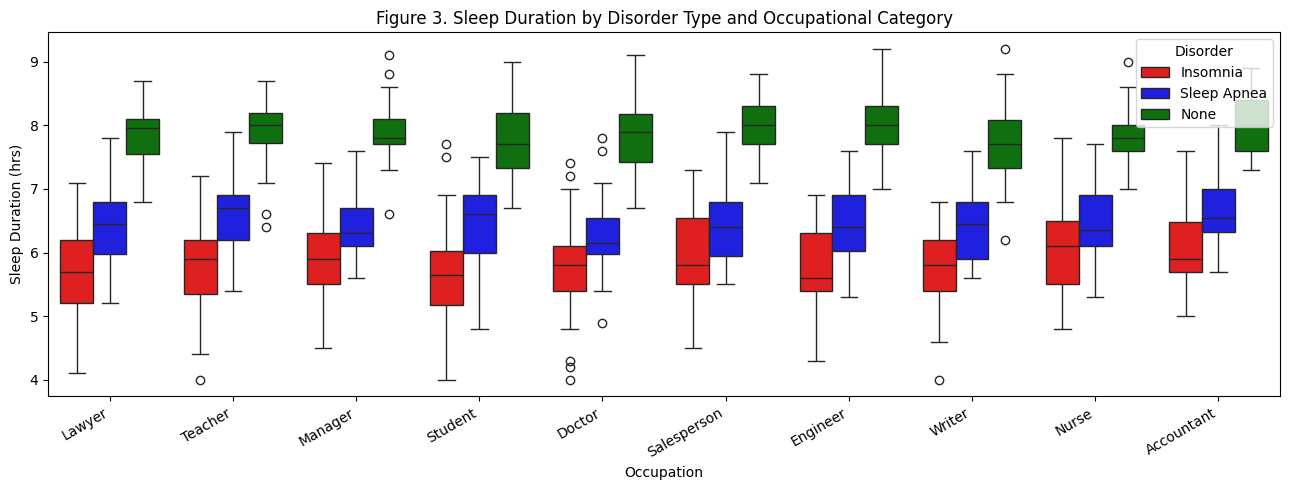

In [11]:
# ── Figure 3: Sleep Duration by Disorder & Occupation ───────
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df, x="Occupation", y="Sleep_Duration",
            hue="Sleep_Disorder", palette=palette, ax=ax)
ax.set_title("Figure 3. Sleep Duration by Disorder Type and Occupational Category")
ax.set_xlabel("Occupation")
ax.set_ylabel("Sleep Duration (hrs)")
ax.legend(title="Disorder", loc="upper right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

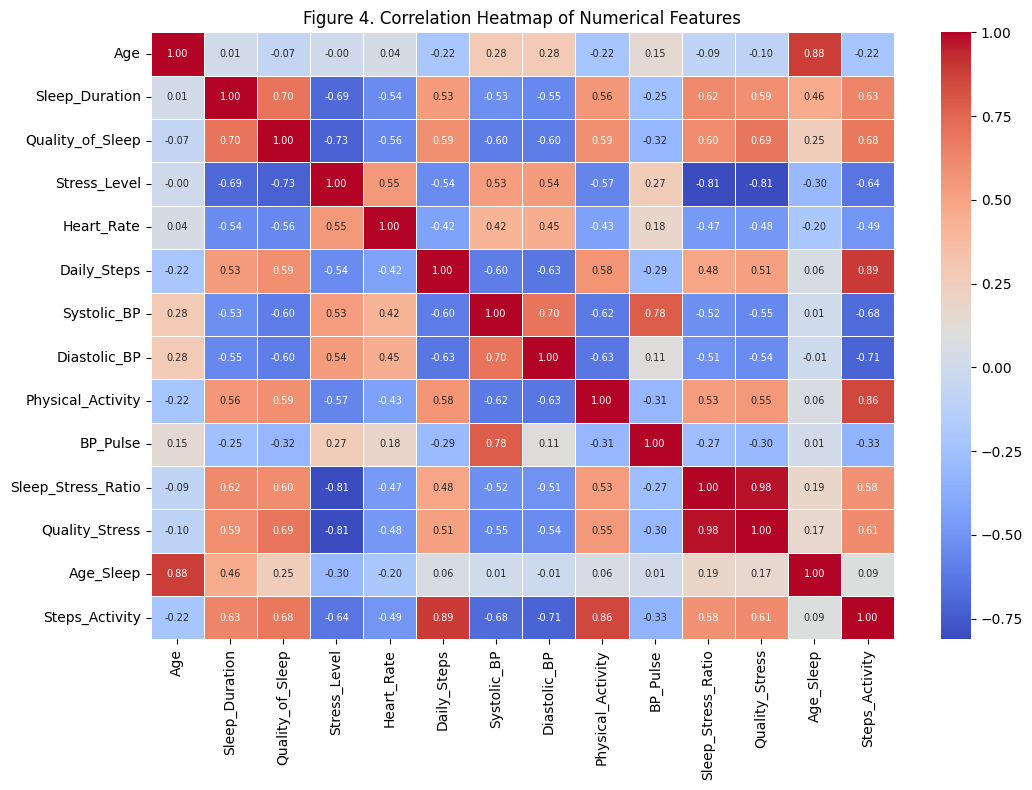

In [12]:
# ── Figure 4: Correlation Heatmap ───────────────────────────
num_cols = ["Age", "Sleep_Duration", "Quality_of_Sleep", "Stress_Level",
            "Heart_Rate", "Daily_Steps", "Systolic_BP", "Diastolic_BP",
            "Physical_Activity", "BP_Pulse", "Sleep_Stress_Ratio",
            "Quality_Stress", "Age_Sleep", "Steps_Activity"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, annot_kws={"size": 7})
ax.set_title("Figure 4. Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

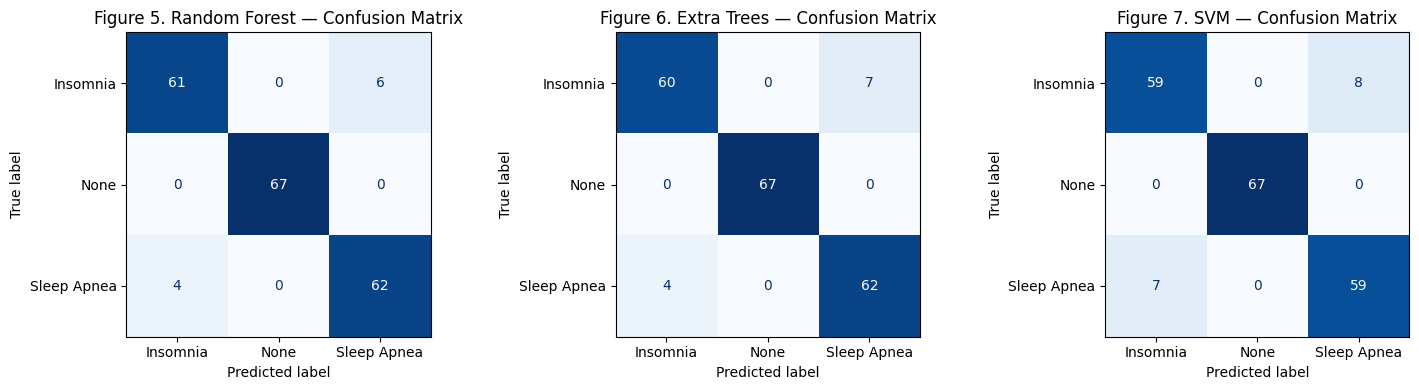

In [13]:
# ── Figures 5-7: Confusion Matrices ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ax, (name, (model, X_eval))) in enumerate(zip(axes, models.items())):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Figure {5+i}. {name} — Confusion Matrix")
plt.tight_layout()
plt.show()

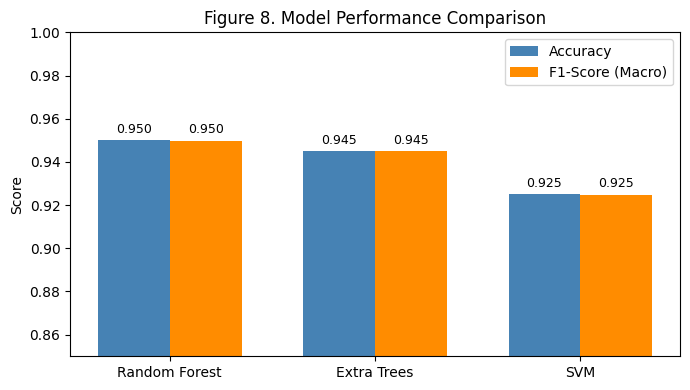

In [14]:
# ── Figure 8: Model Performance Comparison ──────────────────
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(results_df))
width = 0.35
bars1 = ax.bar(x - width/2, results_df["Accuracy"],         width, label="Accuracy",         color="steelblue")
bars2 = ax.bar(x + width/2, results_df["F1-Score (Macro)"], width, label="F1-Score (Macro)", color="darkorange")
ax.set_ylim(0.85, 1.00)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index)
ax.set_ylabel("Score")
ax.set_title("Figure 8. Model Performance Comparison")
ax.legend()
for bar in [*bars1, *bars2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

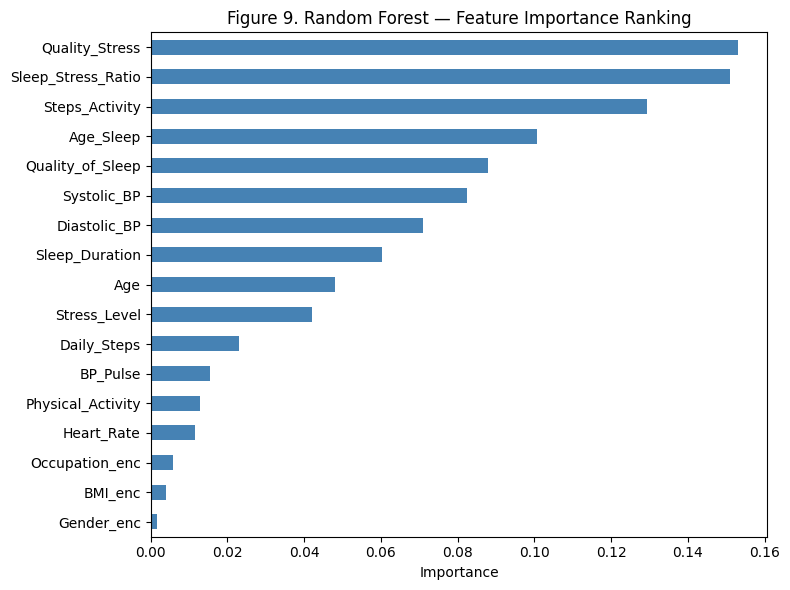

In [15]:
# ── Figure 9: Random Forest Feature Importance ──────────────
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Figure 9. Random Forest — Feature Importance Ranking")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()